# Ejercicio análisis time series
Para este ejercicio vas a trabajar con el histórico de valores en bolsa de una empresa que se dedica a vender muebles. Se pide
1. Importa los datos `df_furniture.csv`
2. Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas
3. ¿De qué fecha a qué fecha va el histórico?
4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?
6. Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?
7. Estaría bien visualizar todos los componentes de la serie temporal por separado
8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional
9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación. ¿Esto es bueno para los modelos?
10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?
11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# librerías estadísticas para análisis de series temporales
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.nonparametric.smoothers_lowess import lowess

import warnings
warnings.filterwarnings('ignore')

# estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Cargamos los datos

In [ ]:
# cargo el CSV con los datos de precios ajustados de muebles
df = pd.read_csv('data\df_furniture.csv')

print(df.shape)
print()
display(df.head(11))
print()
print(df.dtypes)

(331, 2)



,Month,furniture_price_adjusted
0,1992-01-01,2073.432724
1,1992-02-01,2114.485812
2,1992-03-01,2260.570891
3,1992-04-01,2255.103236
4,1992-05-01,2331.414618
5,1992-06-01,2384.638567
6,1992-07-01,2417.165376
7,1992-08-01,2445.498729
8,1992-09-01,2387.351705
9,1992-10-01,2489.350838



Month                        object
furniture_price_adjusted    float64
dtype: object


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     326 non-null    object 
 1   furniture_price_adjusted  331 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.3+ KB


In [39]:
df = df.dropna(subset=['Month'])
# elimino las filas con nans

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 326 entries, 0 to 330
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     326 non-null    object 
 1   furniture_price_adjusted  326 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.6+ KB


## 2. Tratar la fecha como texto e interpretar (parse)

In [41]:
# la columna 'Month' llega como 'str'
# la descompongo en año, mes y día manualmente y luego la reconstruyo como 'datetime' de pandas
# este proceso es útil cuando 'parse_dates' no consigue interpretar el formato automáticamente

In [42]:
# separo por el delimitador '-' para obtener año, mes y día por separado
df[['year', 'month', 'day']] = df['Month'].str.split('-', expand=True)

# convierto cada componente a entero
df['year']  = df['year'].astype(int)
df['month'] = df['month'].astype(int)
df['day']   = df['day'].astype(int)

# paso col de fecha en formato datetime
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# fecha como índice, clave para que pandas trate la serie temporalmente
df = df.set_index('date')

# me quedo solo con la columna de precio ajustado
df = df[['furniture_price_adjusted']]

print(df.index.dtype)

datetime64[ns]


In [43]:
df.head(11)

,furniture_price_adjusted
date,
1992-01-01,2073.432724
1992-02-01,2114.485812
1992-03-01,2260.570891
1992-04-01,2255.103236
1992-05-01,2331.414618
1992-06-01,2384.638567
1992-07-01,2417.165376
1992-08-01,2445.498729
1992-09-01,2387.351705


## 3. ¿De qué fecha a qué fecha va el histórico?

In [44]:
# el índice, al ser datetime, expone .min() y .max() directamente
fecha_inicio = df.index.min()
fecha_fin = df.index.max()
n_meses = len(df)

print(f'Fecha de inicio : {fecha_inicio.strftime("%Y-%m-%d")}')
print(f'Fecha de fin    : {fecha_fin.strftime("%Y-%m-%d")}')
print(f'Total de muestras: {n_meses} meses '
      f'({round(n_meses/12, 1)} años aproximadamente)')

Fecha de inicio : 1992-01-01
Fecha de fin    : 2019-07-01
Total de muestras: 326 meses (27.2 años aproximadamente)


## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?

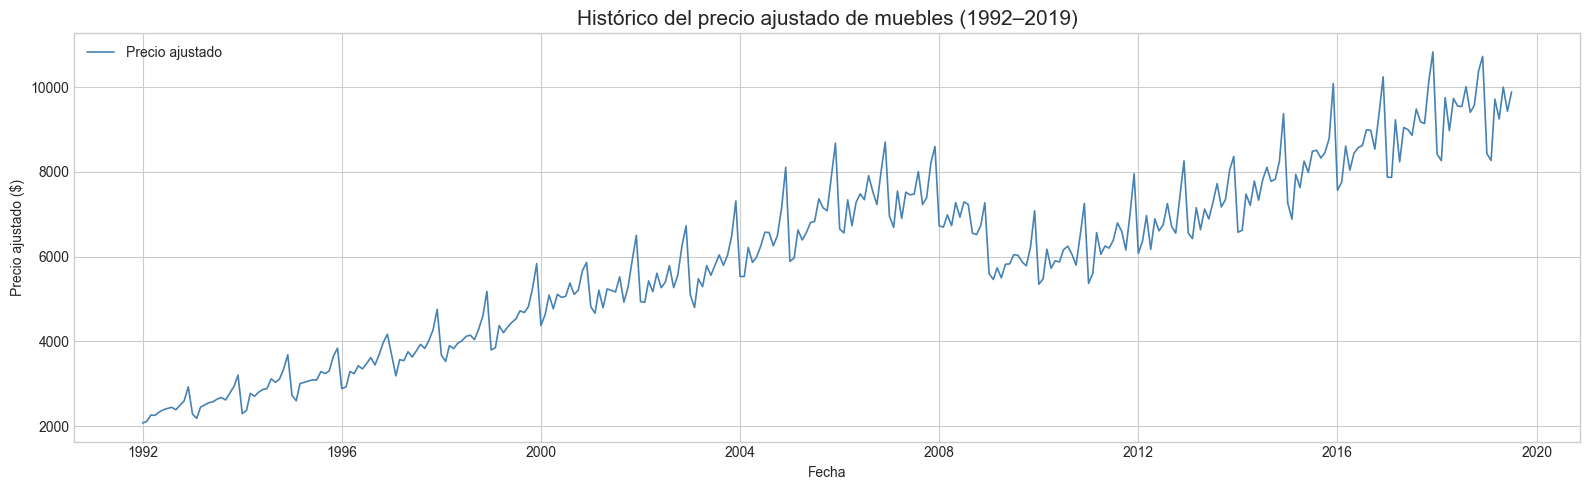


Observaciones visuales:
────────────────────────────────────────────────────────
✔ TENDENCIA CRECIENTE clara a lo largo de los ~27 años.
  El precio pasa de ~2000$ a ~10000$, es decir, se ha
  multiplicado aproximadamente por 5.

✔ ESTACIONALIDAD apreciable: se observan picos y valles
  que se repiten con cierta regularidad dentro de cada año.
  Esto indica un patrón cíclico de período ~12 meses.

✔ VARIANZA creciente: la amplitud de las oscilaciones
  aumenta con el tiempo, lo que sugiere un modelo
  multiplicativo en lugar de aditivo.
────────────────────────────────────────────────────────



In [45]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['furniture_price_adjusted'], color='steelblue', linewidth=1.2, label='Precio ajustado')
ax.set_title('Histórico del precio ajustado de muebles (1992–2019)', fontsize=15)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio ajustado ($)')
ax.legend()
plt.tight_layout()
plt.show()

print("""
Observaciones visuales:
────────────────────────────────────────────────────────
✔ TENDENCIA CRECIENTE clara a lo largo de los ~27 años.
  El precio pasa de ~2000$ a ~10000$, es decir, se ha
  multiplicado aproximadamente por 5.

✔ ESTACIONALIDAD apreciable: se observan picos y valles
  que se repiten con cierta regularidad dentro de cada año.
  Esto indica un patrón cíclico de período ~12 meses.

✔ VARIANZA creciente: la amplitud de las oscilaciones
  aumenta con el tiempo, lo que sugiere un modelo
  multiplicativo en lugar de aditivo.
────────────────────────────────────────────────────────
""")

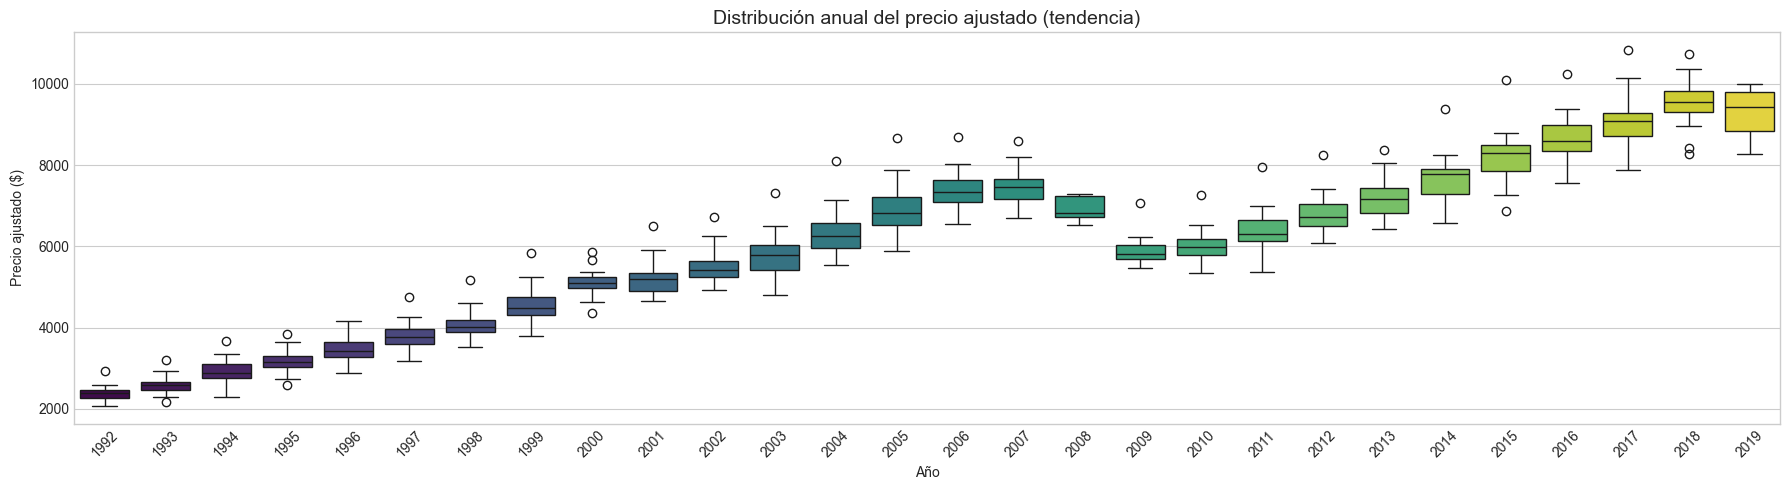

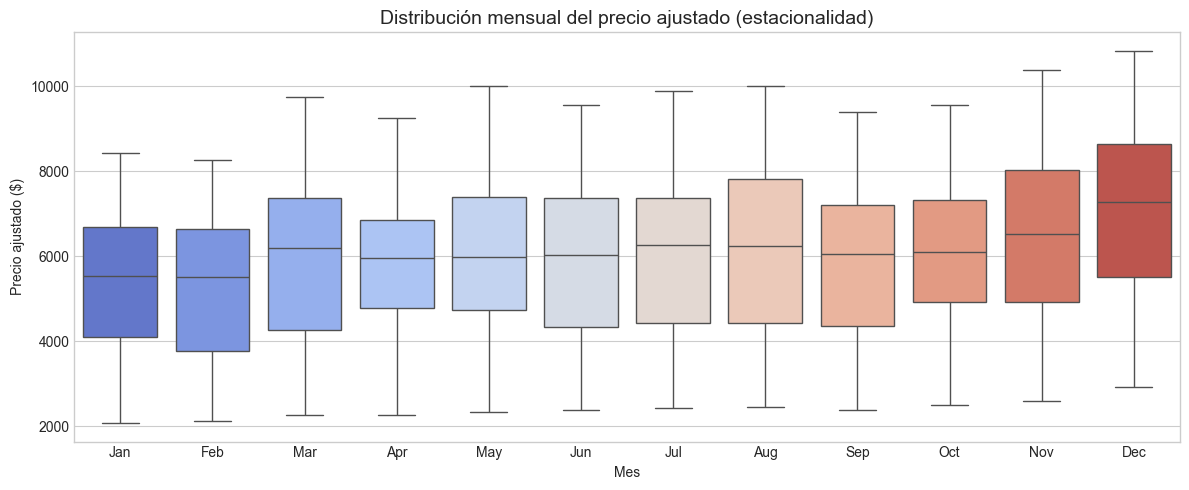

In [46]:
# visualización adicional: boxplot anual para ver la tendencia y variabilidad año a año
df_box = df.copy()
df_box['year'] = df_box.index.year

fig, ax = plt.subplots(figsize=(18, 5))
sns.boxplot(x='year', y='furniture_price_adjusted', data=df_box, ax=ax, hue='year', legend=False, palette='viridis')
ax.set_title('Distribución anual del precio ajustado (tendencia)', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Precio ajustado ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# boxplot mensual para la estacionalidad
df_box['month'] = df_box.index.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(x='month', y='furniture_price_adjusted', data=df_box, order=month_order, ax=ax, hue='month', legend=False, palette='coolwarm')
ax.set_title('Distribución mensual del precio ajustado (estacionalidad)', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Precio ajustado ($)')
plt.tight_layout()
plt.show()

## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?

In [47]:
# estacionariedad implica que la media, varianza y autocovarianza de la serie no cambian
# con el tiempo
# es un requisito para muchos modelos de series temporales (ARIMA, SARIMA)

# usaré dos tests complementarios:
#   ADF (Augmented Dickey-Fuller)**: H₀ = la serie NO es estacionaria (tiene raíz unitaria).
#       P-valor > 0.05 → no rechazo H₀ → NO estacionaria.
#   KPSS (Kwiatkowski-Phillips-Schmidt-Shin)**: H₀ = la serie SÍ es estacionaria.
#       P-valor < 0.05 → rechazo H₀ → NO estacionaria.

In [48]:
serie = df['furniture_price_adjusted'].values

# test 1: Augmented Dickey-Fuller
# H0: la serie tiene raíz unitaria → NO es estacionaria
# Si p-valor > 0.05, no podemos rechazar H0 → serie NO estacionaria
adf_result = adfuller(serie)
print('═' * 55)
print('TEST 1: Augmented Dickey-Fuller (ADF)')
print('─' * 55)
print(f'  Estadístico ADF : {adf_result[0]:.4f}')
print(f'  P-valor         : {adf_result[1]:.4f}')
print(f'  Valores críticos: {adf_result[4]}')
if adf_result[1] > 0.05:
    print('  → P-valor > 0.05: NO rechazo H0 → Serie NO estacionaria ✗')
else:
    print('  → P-valor < 0.05: Rechazo H0 → Serie SÍ estacionaria ✓')

print()

# test 2: KPSS
# H0: la serie ES estacionaria (alrededor de una constante o tendencia)
# Si p-valor < 0.05, rechazo H0 → serie NO estacionaria
kpss_result = kpss(serie, regression='c', nlags='auto')
print('═' * 55)
print('TEST 2: KPSS (Kwiatkowski-Phillips-Schmidt-Shin)')
print('─' * 55)
print(f'  Estadístico KPSS: {kpss_result[0]:.4f}')
print(f'  P-valor         : {kpss_result[1]:.4f}')
print(f'  Valores críticos: {kpss_result[3]}')
if kpss_result[1] < 0.05:
    print('  → P-valor < 0.05: Rechazo H0 → Serie NO estacionaria ✗')
else:
    print('  → P-valor ≥ 0.05: No rechazo H0 → Serie SÍ estacionaria ✓')

print()
print('─' * 55)
print('CONCLUSIÓN: Ambos tests coinciden en que la serie NO es')
print('estacionaria. Habrá que transformarla antes de modelar.')

═══════════════════════════════════════════════════════
TEST 1: Augmented Dickey-Fuller (ADF)
───────────────────────────────────────────────────────
  Estadístico ADF : -1.0947
  P-valor         : 0.7172
  Valores críticos: {'1%': np.float64(-3.451621854687657), '5%': np.float64(-2.870908950689806), '10%': np.float64(-2.571761810613944)}
  → P-valor > 0.05: NO rechazo H0 → Serie NO estacionaria ✗

═══════════════════════════════════════════════════════
TEST 2: KPSS (Kwiatkowski-Phillips-Schmidt-Shin)
───────────────────────────────────────────────────────
  Estadístico KPSS: 2.5004
  P-valor         : 0.0100
  Valores críticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  → P-valor < 0.05: Rechazo H0 → Serie NO estacionaria ✗

───────────────────────────────────────────────────────
CONCLUSIÓN: Ambos tests coinciden en que la serie NO es
estacionaria. Habrá que transformarla antes de modelar.


## 6. ¿Conoces algún método para representar mejor la tendencia?

In [49]:
# con tantos picos la tendencia queda oculta. Dos métodos habituales para suavizar la serie y extraer la tendencia son:
#   Media móvil (Rolling Mean): promedia los últimos k valores. Sencilla y muy usada.
#   LOWESS: suavizado local ponderado, más robusto y flexible que la media móvil.

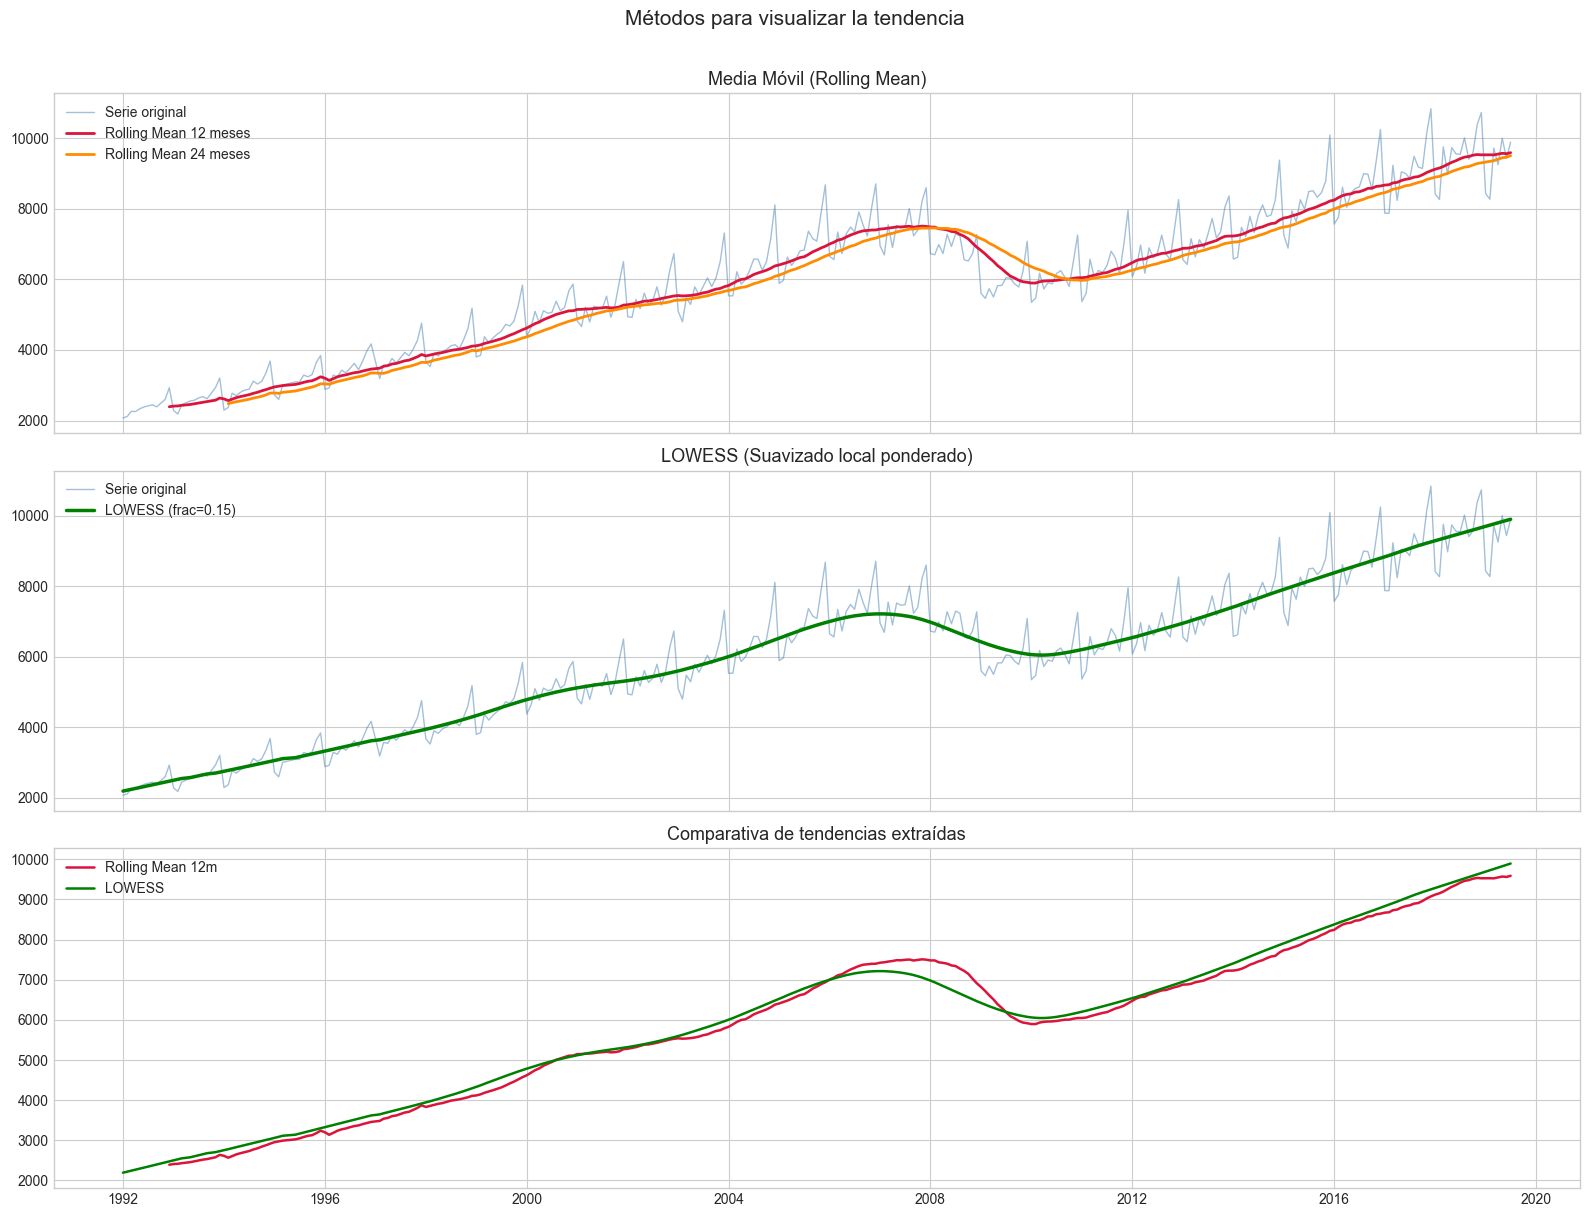


Comentario:
• La Rolling Mean (12 meses) elimina la estacionalidad anual y revela
  la tendencia con claridad. Con 24 meses el suavizado es aún mayor.
• LOWESS es más flexible y no requiere especificar un periodo fijo;
  se adapta mejor a cambios locales de la tendencia.
• Ambos métodos confirman la tendencia creciente claramente visible.



In [50]:
# ,método 1: Rolling Mean
# ventana de 12 meses (un año completo) para capturar la tendencia eliminando
# el ruido de la estacionalidad mensual
rolling_12 = df['furniture_price_adjusted'].rolling(window=12).mean()
rolling_24 = df['furniture_price_adjusted'].rolling(window=24).mean()

# método 2: LOWESS
# frac = fracción de los datos que se usa en cada estimación local
# frac=0.15 → captura bien la tendencia sin sobre-suavizar
y = df['furniture_price_adjusted'].values
x = np.arange(len(y))
lowess_smooth = lowess(y, x, frac=0.15)[:, 1]

# visualización
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# plot original con rolling
axes[0].plot(df.index, df['furniture_price_adjusted'], color='steelblue', alpha=0.5, linewidth=1, label='Serie original')
axes[0].plot(df.index, rolling_12, color='crimson', linewidth=2, label='Rolling Mean 12 meses')
axes[0].plot(df.index, rolling_24, color='darkorange', linewidth=2, label='Rolling Mean 24 meses')
axes[0].set_title('Media Móvil (Rolling Mean)', fontsize=13)
axes[0].legend()

# plot original con LOWESS
axes[1].plot(df.index, df['furniture_price_adjusted'], color='steelblue', alpha=0.5, linewidth=1, label='Serie original')
axes[1].plot(df.index, lowess_smooth, color='green', linewidth=2.5, label='LOWESS (frac=0.15)')
axes[1].set_title('LOWESS (Suavizado local ponderado)', fontsize=13)
axes[1].legend()

# comparativa de ambas tendencias
axes[2].plot(df.index, rolling_12, color='crimson', linewidth=1.8, label='Rolling Mean 12m')
axes[2].plot(df.index, lowess_smooth, color='green', linewidth=1.8, label='LOWESS')
axes[2].set_title('Comparativa de tendencias extraídas', fontsize=13)
axes[2].legend()

plt.suptitle('Métodos para visualizar la tendencia', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print("""
Comentario:
• La Rolling Mean (12 meses) elimina la estacionalidad anual y revela
  la tendencia con claridad. Con 24 meses el suavizado es aún mayor.
• LOWESS es más flexible y no requiere especificar un periodo fijo;
  se adapta mejor a cambios locales de la tendencia.
• Ambos métodos confirman la tendencia creciente claramente visible.
""")

## 7. Estaría bien visualizar todos los componentes de la serie temporal por separado

In [51]:
# la descomposición separa la serie en sus tres componentes básicos:
#   tendencia (Trend): dirección de largo plazo.
#   estacionalidad (Seasonal): patrón que se repite periódicamente.
#   residuo (Residual): variaciones no explicadas por los dos anteriores.

# como la varianza crece con la tendencia, usaremos el modelo multiplicativo (Y = T × S × e).

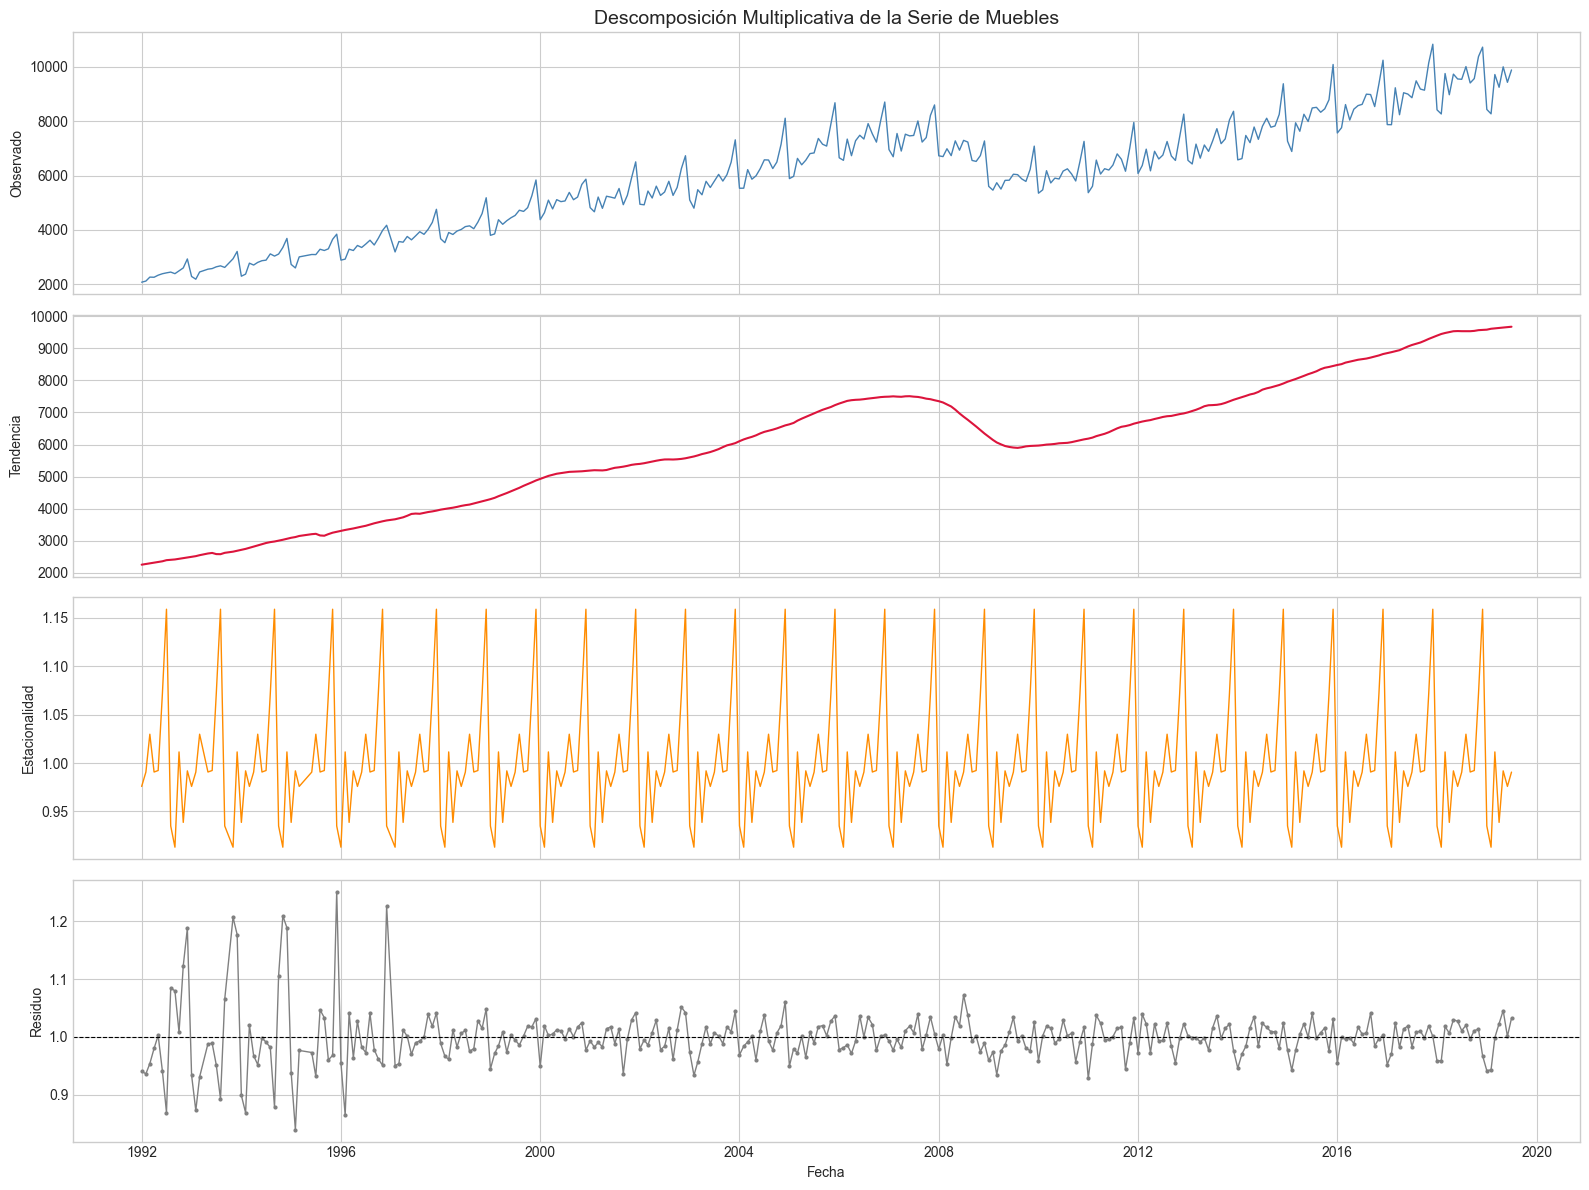


Interpretación de los componentes (modelo multiplicativo):
──────────────────────────────────────────────────────────
• Tendencia  : crecimiento sostenido de 1992 a 2019 con
               cierta aceleración en la segunda mitad.
• Estacional : patrón anual claro y repetitivo. El componente
               estacional actúa como multiplicador (≈ 0.8-1.2).
• Residuo    : debería rondar 1.0 en el modelo multiplicativo.
               Los picos extremos son ruido no explicado por
               tendencia + estacionalidad.
──────────────────────────────────────────────────────────



In [52]:
# period=12 porque los datos son mensuales y el patrón se repite cada 12 meses
# model='multiplicative' porque la amplitud estacional crece con la tendencia
result_mul = seasonal_decompose(
    df['furniture_price_adjusted'],
    model='multiplicative',
    period=12,
    extrapolate_trend='freq'  # Rellena NaN en los extremos de la tendencia
)

# también calculo el aditivo para comparar
result_add = seasonal_decompose(
    df['furniture_price_adjusted'],
    model='additive',
    period=12,
    extrapolate_trend='freq'
)

# gráfica de descomposición
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(result_mul.observed, color='steelblue', linewidth=1)
axes[0].set_ylabel('Observado')
axes[0].set_title('Descomposición Multiplicativa de la Serie de Muebles', fontsize=14)

axes[1].plot(result_mul.trend, color='crimson', linewidth=1.5)
axes[1].set_ylabel('Tendencia')

axes[2].plot(result_mul.seasonal, color='darkorange', linewidth=1)
axes[2].set_ylabel('Estacionalidad')

axes[3].plot(result_mul.resid, color='gray', linewidth=1, marker='o', markersize=2)
axes[3].axhline(1, color='black', linestyle='--', linewidth=0.8)  # En multiplicativo el residuo ideal ≈ 1
axes[3].set_ylabel('Residuo')
axes[3].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

print("""
Interpretación de los componentes (modelo multiplicativo):
──────────────────────────────────────────────────────────
• Tendencia  : crecimiento sostenido de 1992 a 2019 con
               cierta aceleración en la segunda mitad.
• Estacional : patrón anual claro y repetitivo. El componente
               estacional actúa como multiplicador (≈ 0.8-1.2).
• Residuo    : debería rondar 1.0 en el modelo multiplicativo.
               Los picos extremos son ruido no explicado por
               tendencia + estacionalidad.
──────────────────────────────────────────────────────────
""")

## 8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional

In [53]:
# la función de autocorrelación (ACF) mide la correlación entre una serie y sus propios
# valores pasados (lags). Si la serie es estacional, veremos picos significativos en los
# lags múltiplos del período estacional (12, 24, 36...)

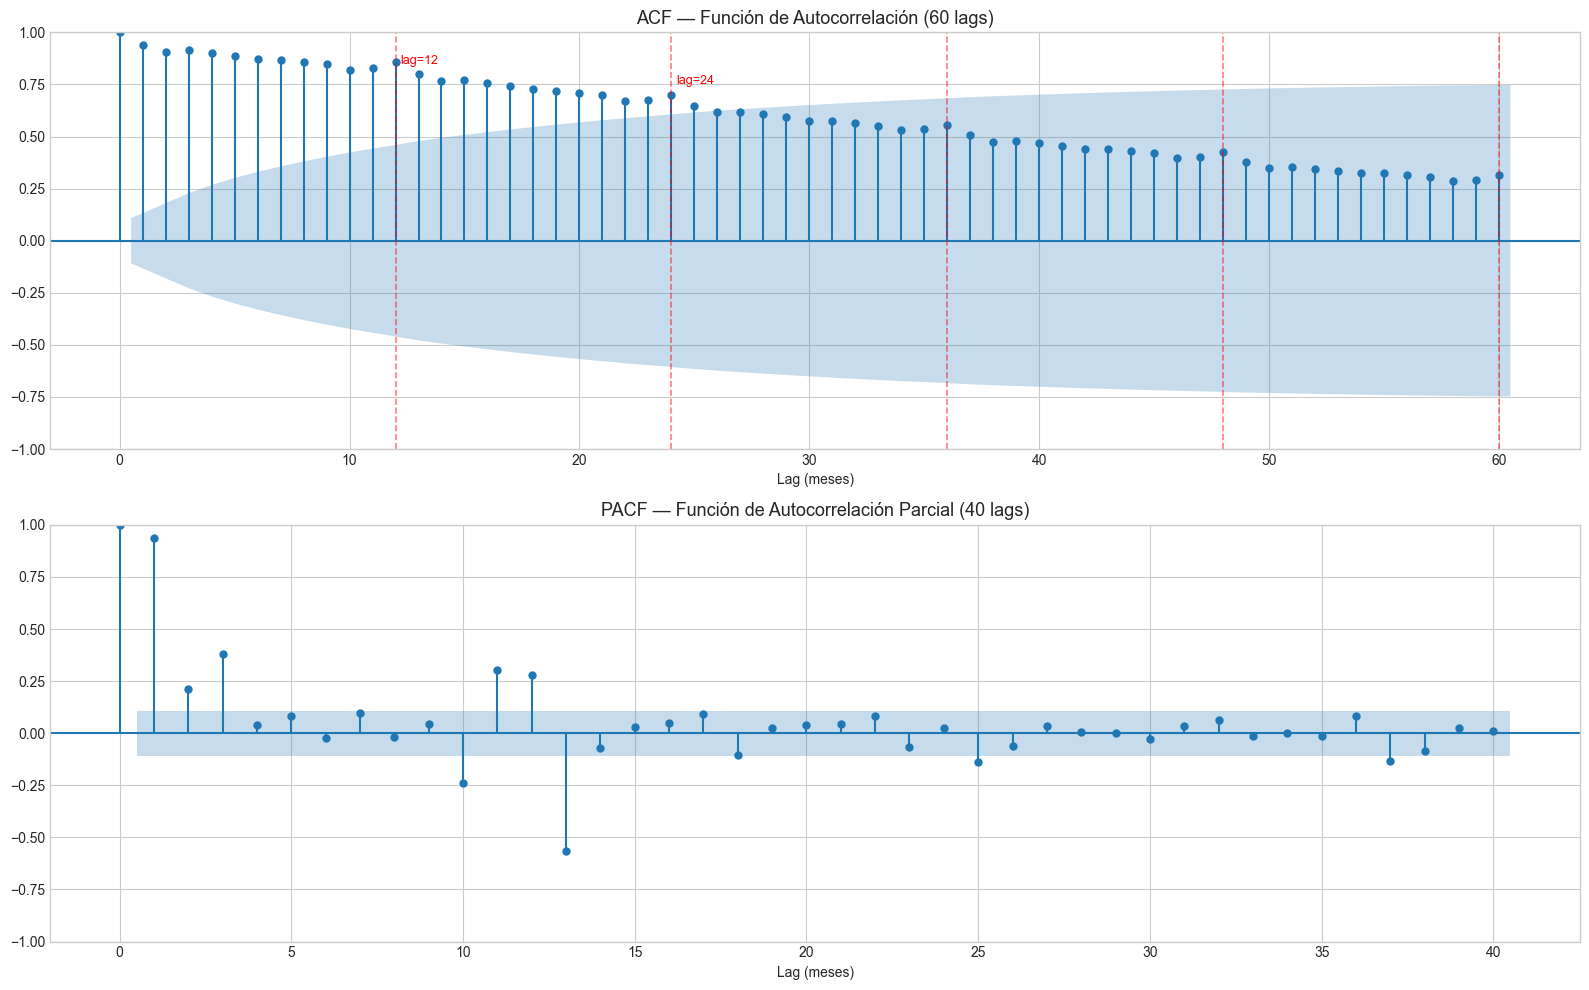


Interpretación del ACF:
───────────────────────────────────────────────────────────────
• La ACF decae MUY lentamente, lo cual es señal de NO estacionariedad
  (la serie tiene tendencia fuerte).

• Se observan picos SIGNIFICATIVOS en los lags 12, 24, 36... (líneas rojas).
  Esto demuestra la ESTACIONALIDAD de período 12 meses.
  La correlación entre el valor de un mes y el mismo mes del año anterior
  es alta y estadísticamente significativa.

• PACF: el primer lag es altísimo (~0.99), lo que confirma que la serie
  tiene tendencia (el valor de hoy depende casi totalmente del de ayer).
  Los lags 12 y 13 también son significativos, apuntando a estacionalidad.
───────────────────────────────────────────────────────────────



In [54]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ACF: Autocorrelation Function
# muestra la correlación de la serie con sus lags
# las barras azules que superan las bandas de confianza grises son significativas
plot_acf(
    df['furniture_price_adjusted'],
    lags=60,          # muestro 60 lags = 5 años
    alpha=0.05,       # nivel de confianza del 95%
    ax=axes[0]
)
axes[0].set_title('ACF — Función de Autocorrelación (60 lags)', fontsize=13)
axes[0].set_xlabel('Lag (meses)')
# merco los múltiplos de 12 para evidenciar la estacionalidad
for lag in [12, 24, 36, 48, 60]:
    axes[0].axvline(x=lag, color='red', linestyle='--', alpha=0.5, linewidth=1.2)
axes[0].text(12.2, 0.85, 'lag=12', color='red', fontsize=9)
axes[0].text(24.2, 0.75, 'lag=24', color='red', fontsize=9)

# PACF: Partial Autocorrelation Function
# muestra la correlación con cada lag eliminando el efecto de los lags intermedios
# útil para determinar el parámetro p del modelo AR
plot_pacf(
    df['furniture_price_adjusted'],
    lags=40,
    alpha=0.05,
    method='ywm',
    ax=axes[1]
)
axes[1].set_title('PACF — Función de Autocorrelación Parcial (40 lags)', fontsize=13)
axes[1].set_xlabel('Lag (meses)')

plt.tight_layout()
plt.show()

print("""
Interpretación del ACF:
───────────────────────────────────────────────────────────────
• La ACF decae MUY lentamente, lo cual es señal de NO estacionariedad
  (la serie tiene tendencia fuerte).

• Se observan picos SIGNIFICATIVOS en los lags 12, 24, 36... (líneas rojas).
  Esto demuestra la ESTACIONALIDAD de período 12 meses.
  La correlación entre el valor de un mes y el mismo mes del año anterior
  es alta y estadísticamente significativa.

• PACF: el primer lag es altísimo (~0.99), lo que confirma que la serie
  tiene tendencia (el valor de hoy depende casi totalmente del de ayer).
  Los lags 12 y 13 también son significativos, apuntando a estacionalidad.
───────────────────────────────────────────────────────────────
""")

## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación.

In [55]:
# creo una representación tabular de la serie con lags de 1 a 5 y calculo la matriz de
# correlación. Esto nos indica cuánta información histórica «recuerda» la serie

Shape del DataFrame con lags: (321, 6)


,t,t-1,t-2,t-3,t-4,t-5
date,,,,,,
1992-06-01,2384.638567,2331.414618,2255.103236,2260.570891,2114.485812,2073.432724
1992-07-01,2417.165376,2384.638567,2331.414618,2255.103236,2260.570891,2114.485812
1992-08-01,2445.498729,2417.165376,2384.638567,2331.414618,2255.103236,2260.570891


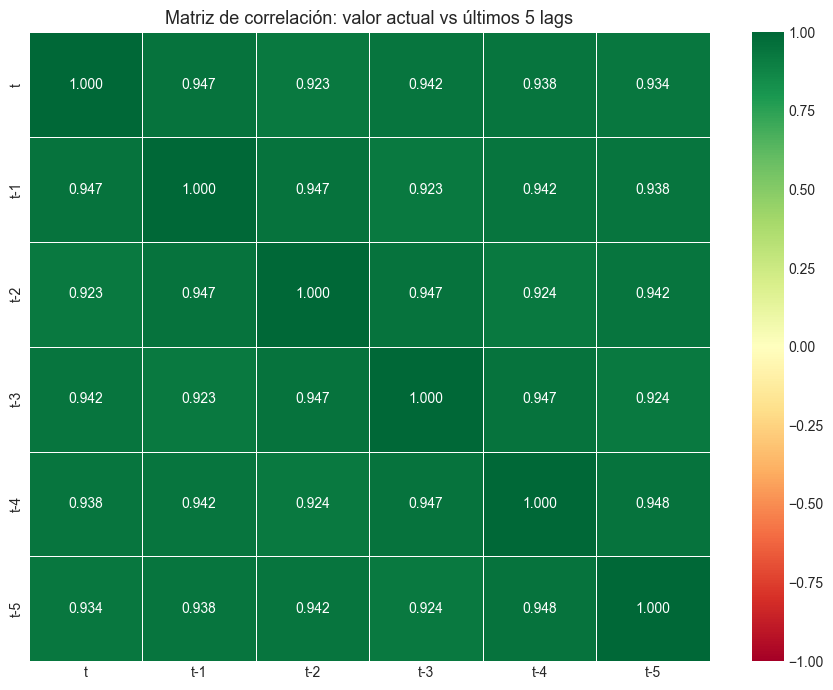


Correlaciones del valor actual (t) con sus lags:
t-1    0.946948
t-2    0.923423
t-3    0.941934
t-4    0.938113
t-5    0.933566

Interpretación:
───────────────────────────────────────────────────────────────
• Todas las correlaciones con los lags son muy altas (>0.99),
  lo que indica una dependencia muy fuerte del pasado reciente.

• ¿Esto es bueno para los modelos? DEPENDE:
  → Es buena señal de que hay información predictiva en el pasado.
  → Pero la altísima correlación entre lags consecutivos (multicolinealidad)
     puede ser problemática para modelos lineales como OLS o AR.
  → Para ARIMA no es problema porque trabaja con diferencias.
  → Para árboles de decisión o Random Forest tampoco, ya que son
     robustos a la multicolinealidad.
───────────────────────────────────────────────────────────────



In [56]:
# creo un DataFrame donde cada columna es un lag de la serie original
# t-1: valor del mes anterior, t-2: dos meses atrás, etc.
df_lags = df[['furniture_price_adjusted']].copy()
df_lags.columns = ['t']

for i in range(1, 6):
    df_lags[f't-{i}'] = df_lags['t'].shift(i)

# elimino las filas con NaN (los primeros 5 registros no tienen todos los lags)
df_lags.dropna(inplace=True)

print('Shape del DataFrame con lags:', df_lags.shape)
display(df_lags.head(3))

# matriz de correlación
corr_matrix = df_lags.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)  # sin máscara: muestro todo
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matriz de correlación: valor actual vs últimos 5 lags', fontsize=13)
plt.tight_layout()
plt.show()

# muestro solo la primera fila (correlación de t con t-1, t-2, ...)
print('\nCorrelaciones del valor actual (t) con sus lags:')
print(corr_matrix['t'].drop('t').to_string())

print("""
Interpretación:
───────────────────────────────────────────────────────────────
• Todas las correlaciones con los lags son muy altas (>0.99),
  lo que indica una dependencia muy fuerte del pasado reciente.

• ¿Esto es bueno para los modelos? DEPENDE:
  → Es buena señal de que hay información predictiva en el pasado.
  → Pero la altísima correlación entre lags consecutivos (multicolinealidad)
     puede ser problemática para modelos lineales como OLS o AR.
  → Para ARIMA no es problema porque trabaja con diferencias.
  → Para árboles de decisión o Random Forest tampoco, ya que son
     robustos a la multicolinealidad.
───────────────────────────────────────────────────────────────
""")

## 10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?

In [57]:
# uso el componente estacional extraído en la descomposición y confirmo el período con el ACF

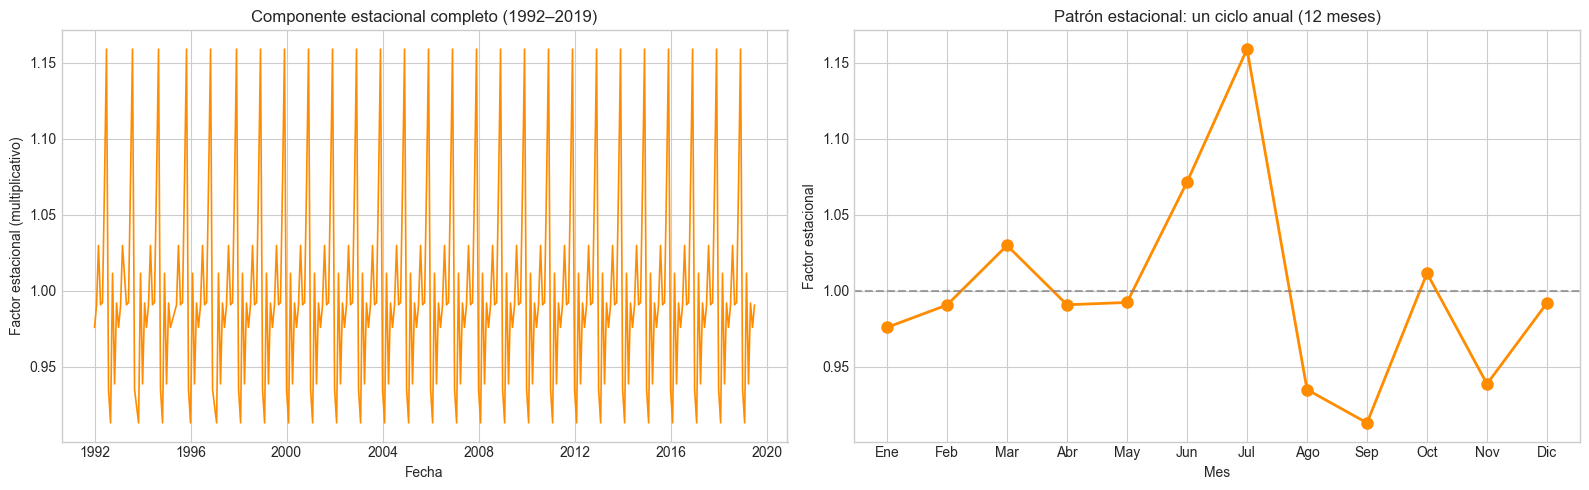

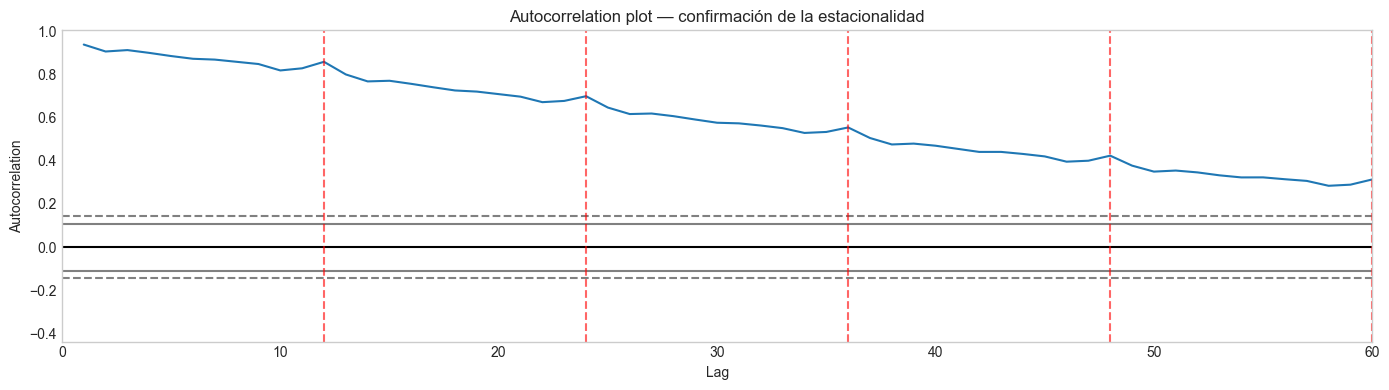


Conclusión:
───────────────────────────────────────────────────────────
El patrón estacional se completa cada 12 instantes (meses).

Evidencias:
1. La descomposición estacional muestra un ciclo que se repite
   exactamente cada 12 posiciones.
2. El ACF presenta picos significativos en lag=12, 24, 36...
3. El boxplot mensual muestra que ciertos meses tienen siempre
   precios más altos/bajos de forma consistente.

→ Período estacional (m) = 12 meses
───────────────────────────────────────────────────────────



In [58]:
# visualización del componente estacional en un solo ciclo
# me quedo con los primeros 24 meses del componente estacional para ver el patrón
seasonal_one_year = result_mul.seasonal.iloc[:24]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# componente estacional completo
axes[0].plot(result_mul.seasonal, color='darkorange', linewidth=1.2)
axes[0].set_title('Componente estacional completo (1992–2019)', fontsize=12)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Factor estacional (multiplicativo)')

# patrón dentro de un año
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
axes[1].plot(range(1, 13), result_mul.seasonal.values[:12],
             marker='o', color='darkorange', linewidth=2, markersize=8)
axes[1].axhline(1, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses)
axes[1].set_title('Patrón estacional: un ciclo anual (12 meses)', fontsize=12)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Factor estacional')

plt.tight_layout()
plt.show()

# confirmo con el ACF calculando la autocorrelación manual
from pandas.plotting import autocorrelation_plot
fig, ax = plt.subplots(figsize=(14, 4))
autocorrelation_plot(df['furniture_price_adjusted'], ax=ax)
ax.set_title('Autocorrelation plot — confirmación de la estacionalidad', fontsize=12)
ax.set_xlim(0, 60)
for lag in [12, 24, 36, 48, 60]:
    ax.axvline(x=lag, color='red', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
Conclusión:
───────────────────────────────────────────────────────────
El patrón estacional se completa cada 12 instantes (meses).

Evidencias:
1. La descomposición estacional muestra un ciclo que se repite
   exactamente cada 12 posiciones.
2. El ACF presenta picos significativos en lag=12, 24, 36...
3. El boxplot mensual muestra que ciertos meses tienen siempre
   precios más altos/bajos de forma consistente.

→ Período estacional (m) = 12 meses
───────────────────────────────────────────────────────────
""")

## 11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [59]:
# hay tres estrategias principales para eliminar la tendencia de una serie:
#   diferenciación: restar el valor anterior → X_t - X_{t-1}
#   restar la tendencia extraída de la descomposición
#   transformación logarítmica + diferenciación**: útil cuando la varianza crece con el nivel

# verifico con el test ADF que, tras la transformación, la serie sí es estacionaria.

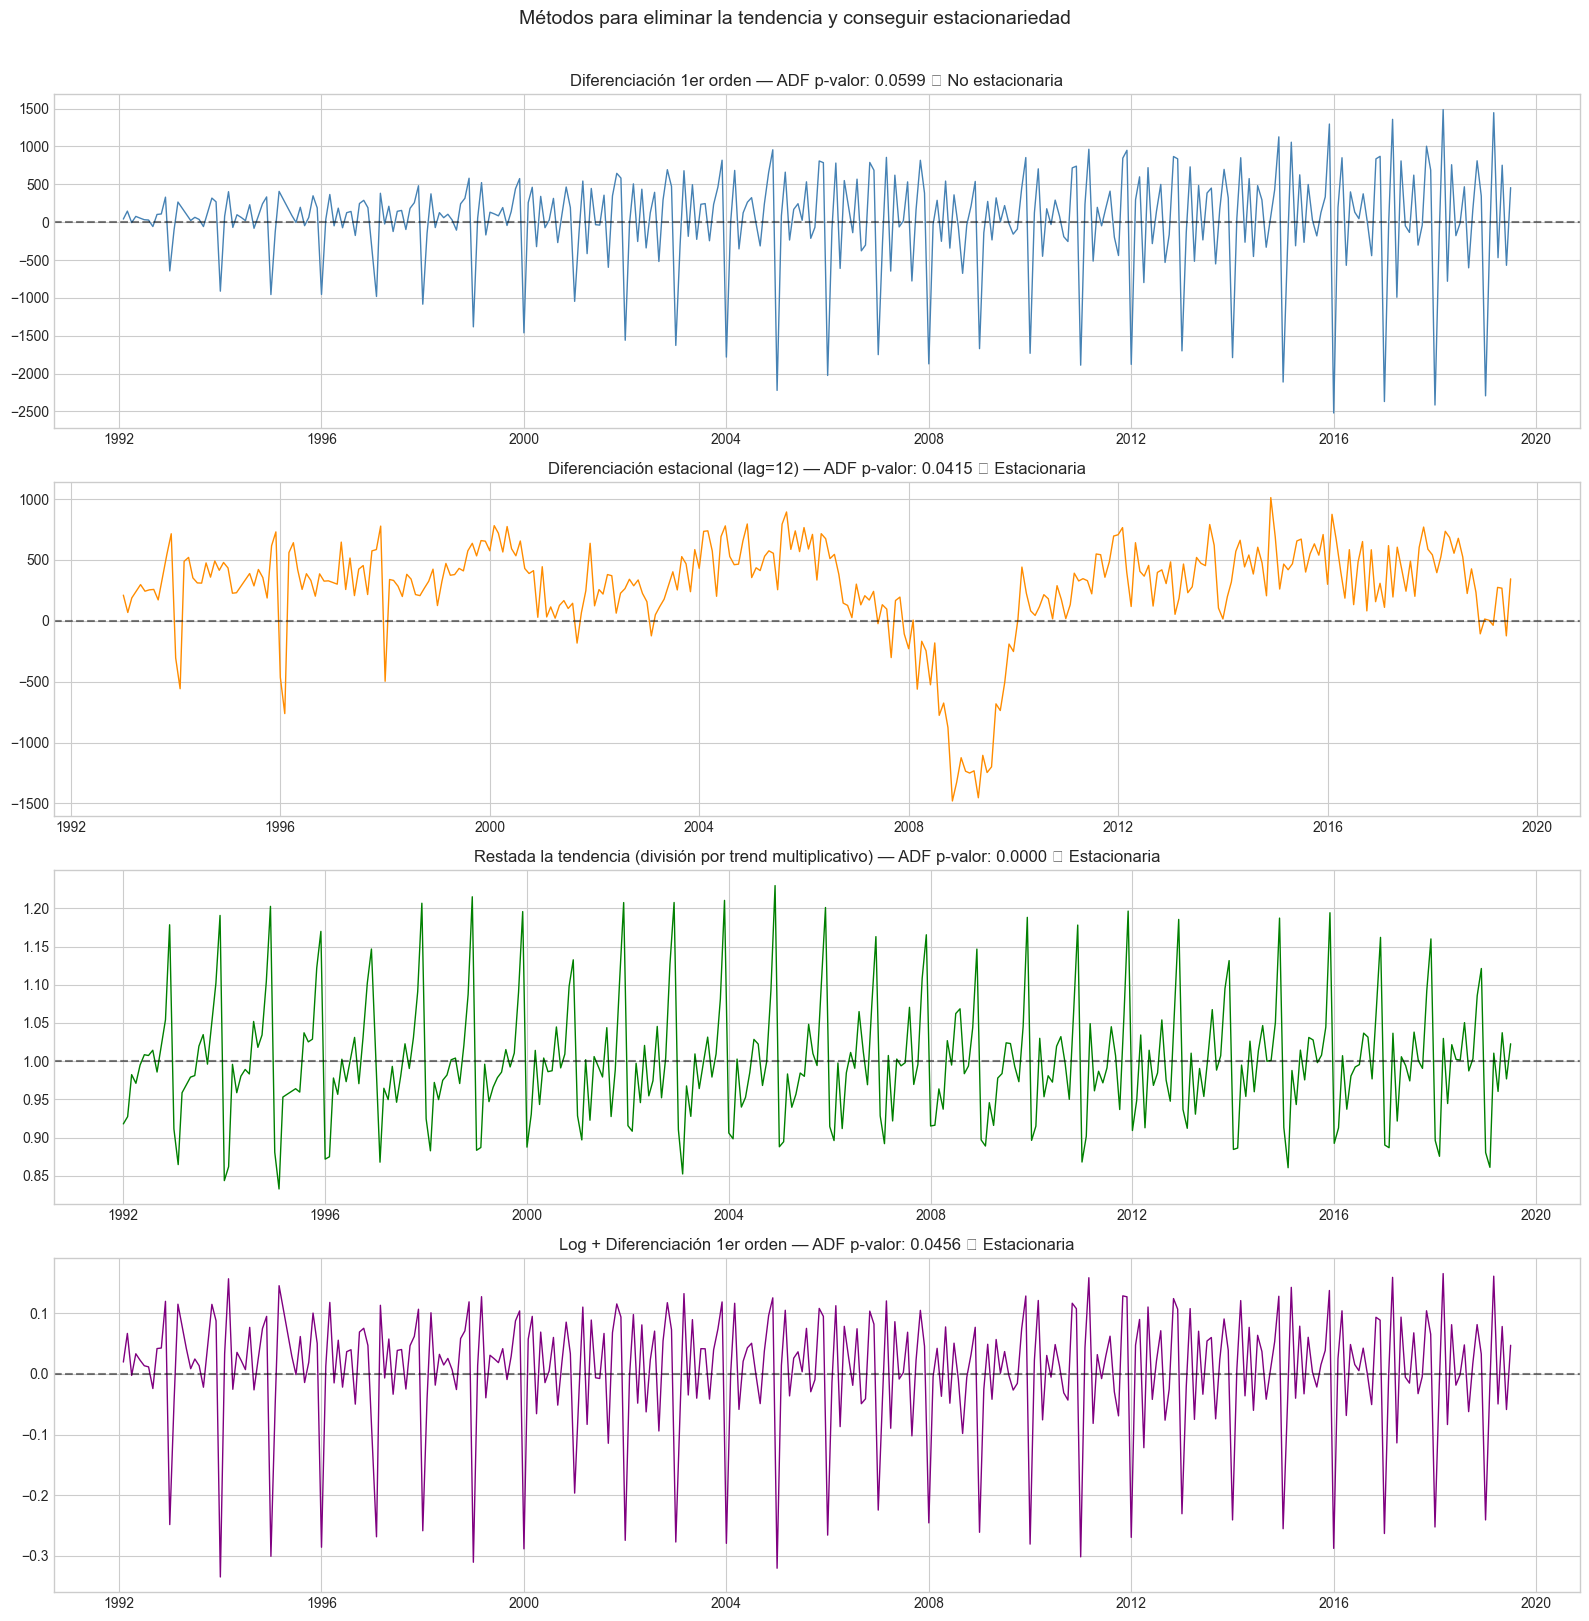


Resumen de resultados ADF (p-valor < 0.05 → estacionaria):
─────────────────────────────────────────────────────────
  Diferenciación 1er orden      : p = 0.0599   ✗
  Diferenciación estacional (12): p = 0.0415   ✓
  Dividir por trend              : p = 0.0000   ✓
  Log + Diferenciación 1er orden : p = 0.0456   ✓

Recomendación:
• Para ARIMA → usar d=1 (diferenciación automática dentro del modelo)
• Para SARIMA → usar d=1, D=1 (diferenciación + estacional)
• Para modelos tabulares (RF, DT) → preferible Log + diff para
  estabilizar varianza y facilitar el aprendizaje.
─────────────────────────────────────────────────────────



In [62]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=False)

# método 1: Diferenciación de primer orden
# calcula X_t - X_{t-1}. Elimina tendencia lineal
diff_1 = df['furniture_price_adjusted'].diff(1).dropna()
adf_diff1 = adfuller(diff_1.values)[1]

axes[0].plot(diff_1, color='steelblue', linewidth=1)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title(f'Diferenciación 1er orden — ADF p-valor: {adf_diff1:.4f} '
                  f'{"✓ Estacionaria" if adf_diff1 < 0.05 else "✗ No estacionaria"}',
                  fontsize=12)

# método 2: Diferenciación estacional (lag=12)
# Calcula X_t - X_{t-12}. Elimina tanto tendencia como estacionalidad anual
diff_12 = df['furniture_price_adjusted'].diff(12).dropna()
adf_diff12 = adfuller(diff_12.values)[1]

axes[1].plot(diff_12, color='darkorange', linewidth=1)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title(f'Diferenciación estacional (lag=12) — ADF p-valor: {adf_diff12:.4f} '
                  f'{"✓ Estacionaria" if adf_diff12 < 0.05 else "✗ No estacionaria"}',
                  fontsize=12)

# método 3: Restar la tendencia de la descomposición
# divide el valor observado entre la tendencia (modelo multiplicativo)
# o resta la tendencia (modelo aditivo)
detrended = df['furniture_price_adjusted'].values / result_mul.trend.values
detrended_series = pd.Series(detrended, index=df.index).dropna()
adf_detrended = adfuller(detrended_series.values)[1]

axes[2].plot(detrended_series, color='green', linewidth=1)
axes[2].axhline(1, color='black', linestyle='--', alpha=0.5)
axes[2].set_title(f'Restada la tendencia (división por trend multiplicativo) — ADF p-valor: {adf_detrended:.4f} '
                  f'{"✓ Estacionaria" if adf_detrended < 0.05 else "✗ No estacionaria"}',
                  fontsize=12)

# método 4: Log + diferenciación 1er orden
# log estabiliza la varianza creciente; la diferenciación elimina la tendencia
log_series = np.log(df['furniture_price_adjusted'])
log_diff   = log_series.diff(1).dropna()
adf_logdiff = adfuller(log_diff.values)[1]

axes[3].plot(log_diff, color='purple', linewidth=1)
axes[3].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[3].set_title(f'Log + Diferenciación 1er orden — ADF p-valor: {adf_logdiff:.4f} '
                  f'{"✓ Estacionaria" if adf_logdiff < 0.05 else "✗ No estacionaria"}',
                  fontsize=12)

plt.suptitle('Métodos para eliminar la tendencia y conseguir estacionariedad',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"""
Resumen de resultados ADF (p-valor < 0.05 → estacionaria):
─────────────────────────────────────────────────────────
  Diferenciación 1er orden      : p = {adf_diff1:.4f}   {'✓' if adf_diff1<0.05 else '✗'}
  Diferenciación estacional (12): p = {adf_diff12:.4f}   {'✓' if adf_diff12<0.05 else '✗'}
  Dividir por trend              : p = {adf_detrended:.4f}   {'✓' if adf_detrended<0.05 else '✗'}
  Log + Diferenciación 1er orden : p = {adf_logdiff:.4f}   {'✓' if adf_logdiff<0.05 else '✗'}

Recomendación:
• Para ARIMA → usar d=1 (diferenciación automática dentro del modelo)
• Para SARIMA → usar d=1, D=1 (diferenciación + estacional)
• Para modelos tabulares (RF, DT) → preferible Log + diff para
  estabilizar varianza y facilitar el aprendizaje.
─────────────────────────────────────────────────────────
""")